# Safe Assets Aren't Always Safe
### Evidence from COVID, Rate Hikes, and Trade Volatility
#### Boston College — Final Poster Notebook

In [18]:
# ── Section 0: Imports & Palette ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mtick
import seaborn as sns
import yfinance as yf
from scipy import stats
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# ── Color Palette ─────────────────────────────────────────────────────────────
C_SPX          = '#3987c6'   # blue       — S&P 500
C_TSY          = '#b21f57'   # deep pink  — Treasuries
C_GOLD         = '#E6A817'   # amber      — Gold
C_CHF          = '#542547'   # dark plum  — CHF
C_JPY          = '#e3a5a6'   # soft pink  — JPY
C_USD          = '#7B5EA7'   # purple     — USD
C_REGIME_SHADE = '#bed7f9'   # light blue — regime shading
C_REGIME_LABEL = '#3987c6'   # blue       — regime label text

asset_cols   = ['tsy_ret', 'gold_ret', 'chf_ret', 'jpy_ret', 'usd_ret']
asset_labels = ['Treasuries', 'Gold', 'CHF', 'JPY', 'USD']
asset_colors = [C_TSY, C_GOLD, C_CHF, C_JPY, C_USD]

asset_map = [
    ('spx_ret',  'S&P 500',    C_SPX),
    ('tsy_ret',  'Treasuries', C_TSY),
    ('gold_ret', 'Gold',       C_GOLD),
    ('chf_ret',  'CHF',        C_CHF),
    ('jpy_ret',  'JPY',        C_JPY),
    ('usd_ret',  'USD',        C_USD),
]

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'axes.facecolor':    'white',
    'figure.facecolor':  'white',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         False,
    'axes.edgecolor':    '#333333',
    'xtick.color':       '#333333',
    'ytick.color':       '#333333',
    'axes.labelcolor':   '#333333',
    'text.color':        '#1a1a1a',
    'figure.dpi':        150,
    'savefig.facecolor': 'white',
})
print('Imports complete.')

Imports complete.


In [19]:
# ── Section 1: Load Data ─────────────────────────────────────────────────────
def clean_fred(path, col):
    df = pd.read_csv(path, na_values=['.'])
    df.columns = df.columns.str.strip()
    date_col = [c for c in df.columns if 'date' in c.lower()][0]
    df = df.rename(columns={date_col: 'date'})
    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date')[[col]].dropna()
    return df

spx   = clean_fred('SP500.csv',  'SP500')
dgs10 = clean_fred('DGS10.csv',  'DGS10')
dxy   = clean_fred('dxy.csv',    'DTWEXBGS')

tickers = {'GC=F': 'gold', 'USDCHF=X': 'chf_raw', 'USDJPY=X': 'jpy_raw'}
yf_data = {}
for ticker, name in tickers.items():
    raw = yf.download(ticker, start='2019-01-01', end='2026-02-20', progress=False)
    raw.index = pd.to_datetime(raw.index)
    close = raw['Close']
    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]
    yf_data[name] = close.squeeze().rename(name)

print('Data loaded.')
print(f"SPX:   {spx.index[0].date()} – {spx.index[-1].date()} ({len(spx)} rows)")
print(f"DGS10: {dgs10.index[0].date()} – {dgs10.index[-1].date()} ({len(dgs10)} rows)")

Data loaded.
SPX:   2019-01-02 – 2026-02-19 (1793 rows)
DGS10: 2019-01-02 – 2026-02-19 (1783 rows)


In [20]:
# ── Section 2: Return Construction ───────────────────────────────────────────
spx_ret  = np.log(spx['SP500'] / spx['SP500'].shift(1)).rename('spx_ret')

y        = dgs10['DGS10'] / 100
dy       = y.diff()
duration = 10 / (1 + y)
tsy_ret  = (-duration * dy).rename('tsy_ret')
print(f"Duration range: {duration.min():.2f} – {duration.max():.2f}, mean {duration.mean():.2f}")

gold_ret = np.log(yf_data['gold'] / yf_data['gold'].shift(1)).rename('gold_ret')
chf_ret  = (-np.log(yf_data['chf_raw'] / yf_data['chf_raw'].shift(1))).rename('chf_ret')
jpy_ret  = (-np.log(yf_data['jpy_raw'] / yf_data['jpy_raw'].shift(1))).rename('jpy_ret')
usd_ret  = np.log(dxy['DTWEXBGS'] / dxy['DTWEXBGS'].shift(1)).rename('usd_ret')
yield_change = dy.rename('yield_change')

df = pd.concat([spx_ret, tsy_ret, gold_ret, chf_ret, jpy_ret, usd_ret, yield_change], axis=1)
df = df.dropna()
print(f"Master df: {df.index[0].date()} – {df.index[-1].date()}, {len(df)} rows")

Duration range: 9.53 – 9.95, mean 9.72
Master df: 2019-01-03 – 2026-02-19, 1769 rows


In [21]:
# ── Section 3: ADF Stationarity Tests ────────────────────────────────────────
from statsmodels.tsa.stattools import adfuller

print(f"{'Series':<18} {'ADF Stat':>10} {'p-value':>10} {'Stationary?':>12}")
print('-' * 52)
for col in df.columns:
    result = adfuller(df[col].dropna(), autolag='AIC')
    p = result[1]
    print(f"{col:<18} {result[0]:>10.3f} {p:>10.4f} {'YES' if p < 0.05 else 'NO':>12}")

Series               ADF Stat    p-value  Stationary?
----------------------------------------------------
spx_ret               -12.997     0.0000          YES
tsy_ret               -31.699     0.0000          YES
gold_ret              -18.321     0.0000          YES
chf_ret               -16.203     0.0000          YES
jpy_ret               -16.134     0.0000          YES
usd_ret               -12.740     0.0000          YES
yield_change          -31.713     0.0000          YES


In [22]:
# ── Section 4: Regime Definitions ────────────────────────────────────────────
REGIMES = {
    'COVID':            ('2020-02-15', '2021-06-30'),
    'Hike Cycle':       ('2022-01-01', '2023-12-31'),
    'Trade Volatility': ('2025-01-02', '2026-02-19'),
}

LIBERATION_DAY = pd.Timestamp('2025-04-02')

def regime_mask(df, name):
    s, e = REGIMES[name]
    return (df.index >= s) & (df.index <= e)

df['regime'] = 'Calm'
for name, (s, e) in REGIMES.items():
    df.loc[regime_mask(df, name), 'regime'] = name

df['d_covid'] = regime_mask(df, 'COVID').astype(int)
df['d_hike']  = regime_mask(df, 'Hike Cycle').astype(int)
df['d_trade'] = regime_mask(df, 'Trade Volatility').astype(int)

print('Regime observation counts:')
print(df['regime'].value_counts())
print()
print(f"{'Regime':<20} {'Start':>12} {'End':>12} {'N (trading days)':>18}")
print('-' * 65)
for r, (s, e) in REGIMES.items():
    n = regime_mask(df, r).sum()
    print(f"{r:<20} {s:>12} {e:>12} {n:>18}")
print(f"\nLiberation Day: {LIBERATION_DAY.date()} — marked on Trade Volatility charts")

Regime observation counts:
Calm                651
Hike Cycle          497
COVID               341
Trade Volatility    280
Name: regime, dtype: int64

Regime                      Start          End   N (trading days)
-----------------------------------------------------------------
COVID                  2020-02-15   2021-06-30                341
Hike Cycle             2022-01-01   2023-12-31                497
Trade Volatility       2025-01-02   2026-02-19                280

Liberation Day: 2025-04-02 — marked on Trade Volatility charts


In [23]:
print(df.tail(10))

             spx_ret   tsy_ret  gold_ret   chf_ret   jpy_ret   usd_ret  \
2026-02-05 -0.012327  0.007677 -0.012063 -0.001996 -0.007150  0.002054   
2026-02-06  0.019504 -0.000960  0.018304 -0.000502  0.000848 -0.002219   
2026-02-09  0.004680 -0.000000  0.019936  0.002407 -0.002930 -0.005100   
2026-02-10 -0.003309  0.005760 -0.009369  0.011290  0.007097 -0.001000   
2026-02-11 -0.000049 -0.001920  0.013459 -0.001888  0.010624 -0.000523   
2026-02-12 -0.015785  0.008646 -0.029596 -0.003338  0.007883  0.000660   
2026-02-13  0.000499  0.004806  0.019768  0.002064  0.002927 -0.000100   
2026-02-17  0.001031 -0.000961 -0.028089 -0.001808 -0.005418  0.001800   
2026-02-18  0.005551 -0.003843  0.020995 -0.000779  0.002999  0.000892   
2026-02-19 -0.002826  0.000961 -0.002128 -0.002593 -0.010031  0.003328   

            yield_change            regime  d_covid  d_hike  d_trade  
2026-02-05       -0.0008  Trade Volatility        0       0        1  
2026-02-06        0.0001  Trade Volatility 

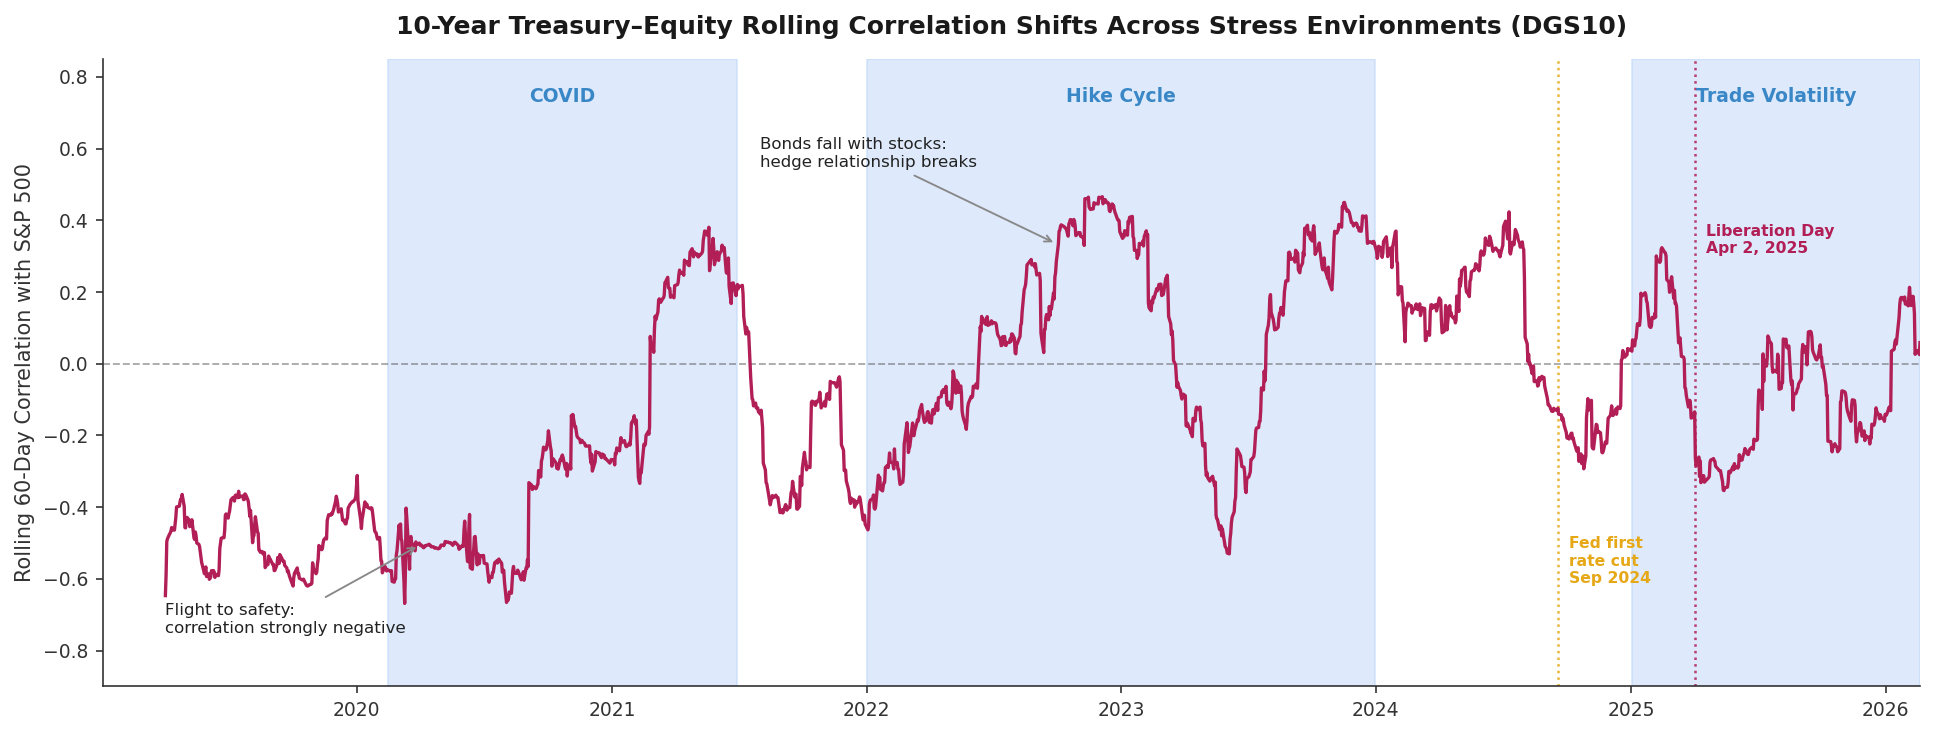

Saved: chart1_intro_rolling_corr.png


In [63]:
# ── CHART 1: Rolling 60-Day Correlation — Introduction Hook ──────────────────
WINDOW = 60

roll_corr = pd.DataFrame(index=df.index)
for col in asset_cols:
    roll_corr[col] = df[col].rolling(WINDOW).corr(df['spx_ret'])

fig, ax = plt.subplots(figsize=(13, 5), facecolor='white')
ax.set_facecolor('white')

for rname, (rs, re) in REGIMES.items():
    ax.axvspan(pd.Timestamp(rs), pd.Timestamp(re),
               color=C_REGIME_SHADE, alpha=0.5, zorder=1)
    mid = pd.Timestamp(rs) + (pd.Timestamp(re) - pd.Timestamp(rs)) / 2
    ax.text(mid, 0.72, rname, ha='center', va='bottom',
            fontsize=9, fontweight='bold', color=C_REGIME_LABEL)

ax.axhline(0, color='#555555', linewidth=0.9, linestyle='--', alpha=0.5, zorder=2)

# ── Fed first rate cut ────────────────────────────────────────────────────────
FED_CUT = pd.Timestamp('2024-09-18')
ax.axvline(FED_CUT, color='#E6A817', linewidth=1.2, linestyle=':', alpha=0.85, zorder=2)
ax.text(FED_CUT, -0.62, '  Fed first\n  rate cut\n  Sep 2024',
        fontsize=7.5, color='#E6A817', fontweight='bold', va='bottom')

# ── Liberation Day ────────────────────────────────────────────────────────────
LIB_DAY = pd.Timestamp('2025-04-02')
ax.axvline(LIB_DAY, color='#b21f57', linewidth=1.2, linestyle=':', alpha=0.85, zorder=2)
ax.text(LIB_DAY, 0.30, '  Liberation Day\n  Apr 2, 2025',
        fontsize=7.5, color='#b21f57', fontweight='bold', va='bottom')

ax.plot(roll_corr.index, roll_corr['tsy_ret'], color=C_TSY, linewidth=1.6, zorder=3)

_rc_valid = roll_corr['tsy_ret'].dropna()
_y_covid  = float(_rc_valid.loc[_rc_valid.index >= '2020-04-01'].iloc[0])
_y_hike   = float(_rc_valid.loc[_rc_valid.index >= '2022-10-01'].iloc[0])
_y_trade  = float(_rc_valid.loc[_rc_valid.index >= '2025-06-01'].iloc[0]) if (_rc_valid.index >= '2025-06-01').any() else float(_rc_valid.iloc[-1])

ax.annotate('Flight to safety:\ncorrelation strongly negative',
            xy=(pd.Timestamp('2020-04-01'), _y_covid),
            xytext=(pd.Timestamp('2019-04-01'), -0.75),
            fontsize=8, color='#222222',
            arrowprops=dict(arrowstyle='->', color='#888888', lw=0.9))

ax.annotate('Bonds fall with stocks:\nhedge relationship breaks',
            xy=(pd.Timestamp('2022-10-01'), _y_hike),
            xytext=(pd.Timestamp('2021-08-01'), 0.55),
            fontsize=8, color='#222222',
            arrowprops=dict(arrowstyle='->', color='#888888', lw=0.9))



ax.set_title('10-Year Treasury–Equity Rolling Correlation Shifts Across Stress Environments (DGS10)',
             fontsize=12, fontweight='bold', pad=12)
ax.set_ylabel('Rolling 60-Day Correlation with S&P 500', fontsize=10)
ax.set_ylim(-0.90, 0.85)
ax.set_xlim(df.index[0], df.index[-1])
ax.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig('chart1_intro_rolling_corr.png', dpi=250, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: chart1_intro_rolling_corr.png')


COVID — 54 stress days
Asset               Mean   CI Lower   CI Upper   Sig
────────────────────────────────────────────────────
Treasuries       +0.289%  [ +0.016%,  +0.543%]  ✓
Gold             -0.035%  [ -0.475%,  +0.329%]  ✗
CHF              +0.052%  [ -0.124%,  +0.228%]  ✗
JPY              -0.038%  [ -0.262%,  +0.097%]  ✗
USD              +0.244%  [ +0.129%,  +0.403%]  ✓

Hike Cycle — 91 stress days
Asset               Mean   CI Lower   CI Upper   Sig
────────────────────────────────────────────────────
Treasuries       -0.108%  [ -0.302%,  +0.104%]  ✗
Gold             -0.122%  [ -0.369%,  +0.125%]  ✗
CHF              +0.036%  [ -0.060%,  +0.111%]  ✗
JPY              -0.132%  [ -0.238%,  -0.016%]  ✓
USD              +0.211%  [ +0.157%,  +0.283%]  ✓

Trade Volatility — 31 stress days
Asset               Mean   CI Lower   CI Upper   Sig
────────────────────────────────────────────────────
Treasuries       +0.171%  [ -0.037%,  +0.362%]  ✗
Gold             +0.345%  [ -0.029%,  +0.990

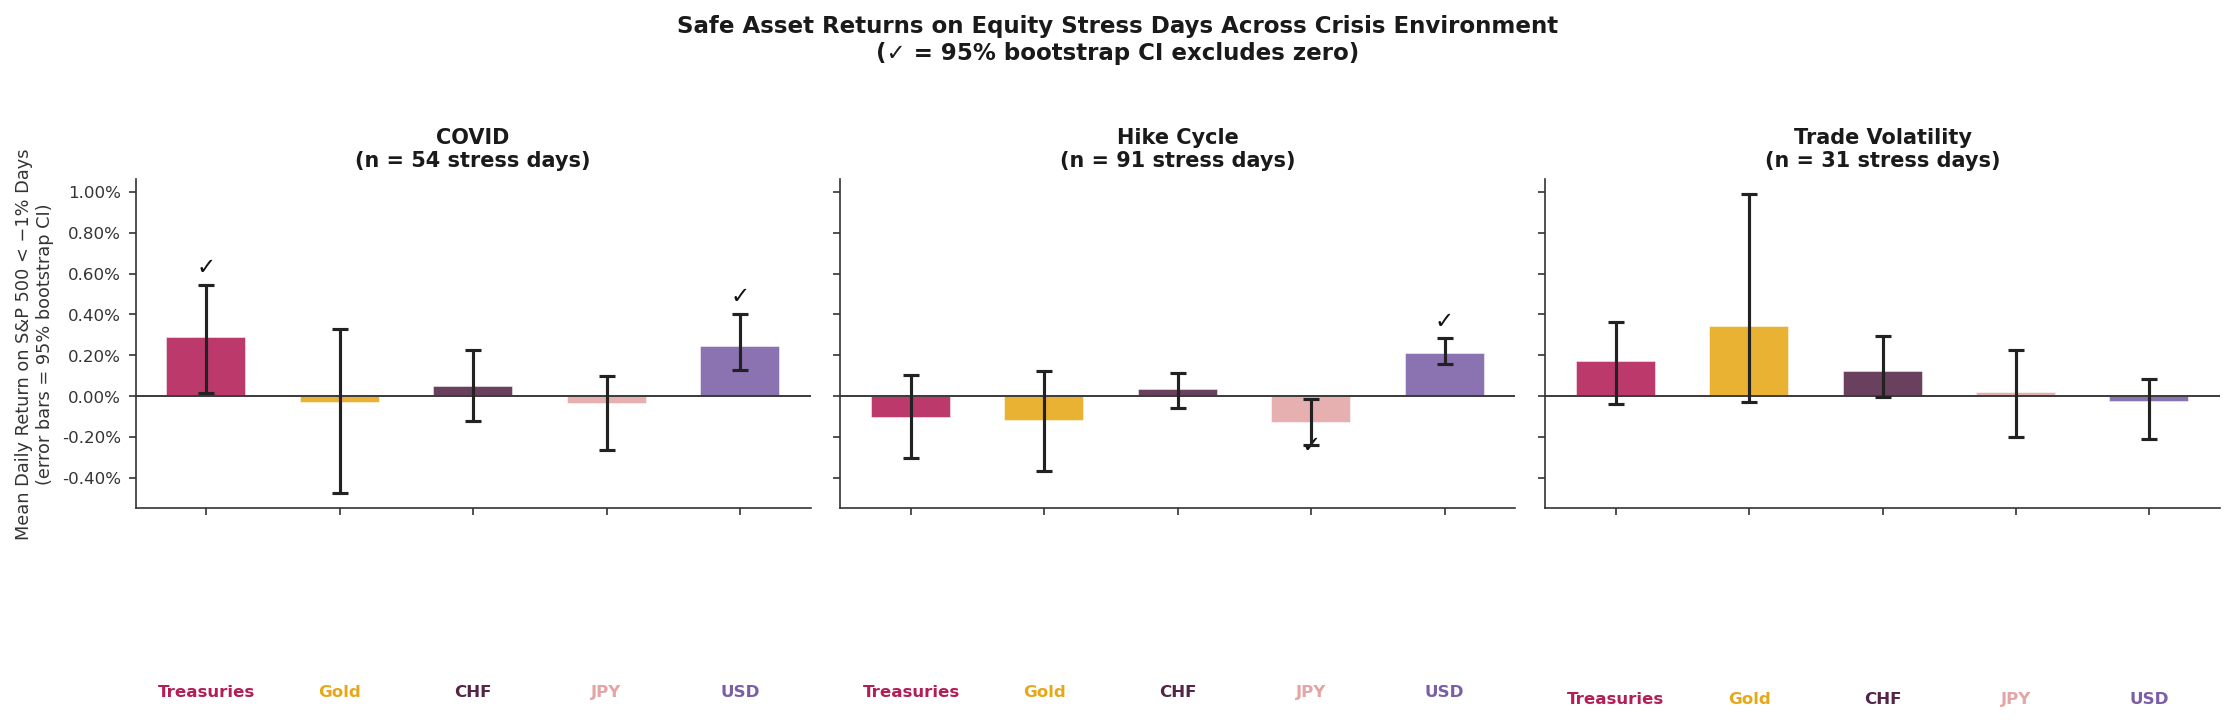

Saved: chart2_bootstrap_stress.png


In [58]:
# ── Block Bootstrap + CHART 2: Stress-Day Returns with 95% CI ────────────────
STRESS_THRESH = -0.01
BLOCK_SIZE    = 5
N_BOOT        = 10000

def block_bootstrap_mean(data, block_size=5, n_bootstrap=10000):
    data  = np.array(data)
    n     = len(data)
    means = []
    for _ in range(n_bootstrap):
        n_blocks  = int(np.ceil(n / block_size))
        starts    = np.random.randint(0, max(1, n - block_size + 1), n_blocks)
        resampled = np.concatenate([data[s:s + block_size] for s in starts])[:n]
        means.append(resampled.mean())
    return np.array(means)

stress_results = {}
boot_results   = {}

for rname in REGIMES:
    mask   = regime_mask(df, rname)
    stress = df[mask & (df['spx_ret'] < STRESS_THRESH)]
    n_days = len(stress)
    res    = {}
    boot   = {}

    print(f"\n{rname} — {n_days} stress days")
    print(f"{'Asset':<14} {'Mean':>9} {'CI Lower':>10} {'CI Upper':>10} {'Sig':>5}")
    print('─' * 52)

    for col, lab in zip(asset_cols, asset_labels):
        vals = stress[col].dropna().values * 100
        if len(vals) < 5:
            continue
        t, p       = stats.ttest_1samp(vals, 0)
        boot_means = block_bootstrap_mean(vals, BLOCK_SIZE, N_BOOT)
        lo, hi     = np.percentile(boot_means, [2.5, 97.5])
        sig        = '✓' if lo > 0 or hi < 0 else '✗'
        res[lab]   = {'mean': vals.mean(), 'p': p, 'n': n_days}
        boot[lab]  = {'mean': vals.mean(), 'ci_lower': lo, 'ci_upper': hi, 'sig': sig}
        print(f"{lab:<14} {vals.mean():>+8.3f}%  [{lo:>+7.3f}%, {hi:>+7.3f}%]  {sig}")

    stress_results[rname] = res
    boot_results[rname]   = boot

# ── CHART 2: Bars + Bootstrap CI ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True, facecolor='white')

for ax, rname in zip(axes, REGIMES):
    boot   = boot_results[rname]
    n_days = next(iter(stress_results[rname].values()))['n']
    labs   = [l for l in asset_labels if l in boot]
    means  = [boot[l]['mean']     for l in labs]
    lowers = [boot[l]['ci_lower'] for l in labs]
    uppers = [boot[l]['ci_upper'] for l in labs]
    sigs   = [boot[l]['sig']      for l in labs]
    colors = [asset_colors[asset_labels.index(l)] for l in labs]

    x = np.arange(len(labs))
    ax.bar(x, means, color=colors, width=0.6,
           edgecolor='white', linewidth=0.8, alpha=0.88)

    yerr_lower = [m - lo for m, lo in zip(means, lowers)]
    yerr_upper = [hi - m for m, hi in zip(means, uppers)]
    ax.errorbar(x, means,
                yerr=[yerr_lower, yerr_upper],
                fmt='none', color='#222222',
                elinewidth=1.5, capsize=4, capthick=1.5, zorder=5)

    ax.axhline(0, color='#333333', linewidth=0.9)
    ax.set_facecolor('white')
    ax.set_xticks(x)
    ax.set_xticklabels([])

    for i, (lab, m, sig) in enumerate(zip(labs, means, sigs)):
        ax.text(i, ax.get_ylim()[0] - 0.01, lab,
                ha='center', va='top', fontsize=8,
                color=colors[i], fontweight='bold',
                transform=ax.get_xaxis_transform())
        y_marker = uppers[i] + 0.03 if m >= 0 else lowers[i] - 0.06
        if sig == '✓':
            ax.text(i, y_marker, '✓', ha='center', va='bottom',
                    fontsize=11, color='#111111', fontweight='bold')

    ax.set_title(f'{rname}\n(n = {n_days} stress days)',
                 fontsize=10, fontweight='bold')
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f%%'))
    ax.tick_params(axis='y', labelsize=8)

axes[0].set_ylabel('Mean Daily Return on S&P 500 < −1% Days\n(error bars = 95% bootstrap CI)',
                   fontsize=8.5)

fig.suptitle('Safe Asset Returns on Equity Stress Days Across Crisis Environment\n'
             '(✓ = 95% bootstrap CI excludes zero)',
             fontsize=11, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('chart2_bootstrap_stress.png', dpi=250, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: chart2_bootstrap_stress.png')

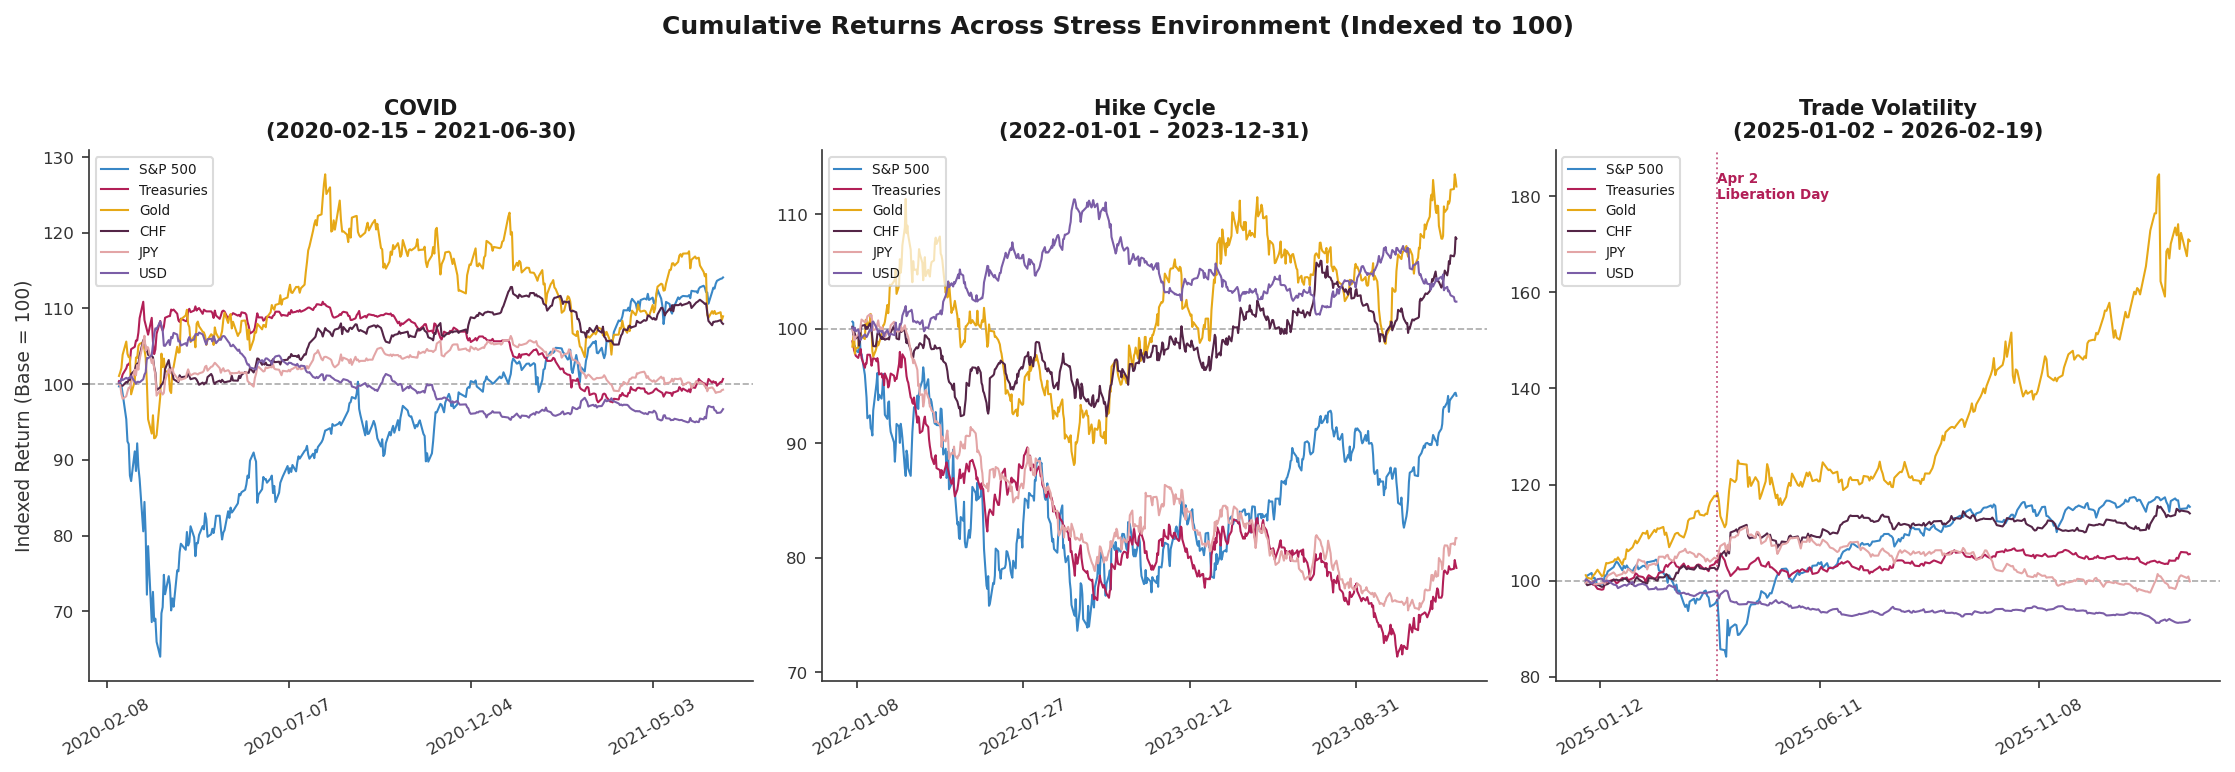

Saved: chart3_cumulative_returns.png


In [57]:
# ── CHART 3: Cumulative Returns Panel — Hero Chart ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor='white')

for ax, (rname, (rs, re)) in zip(axes, REGIMES.items()):
    mask = regime_mask(df, rname)
    sub  = df[mask].copy()
    ax.axhline(100, color='#AAAAAA', linewidth=0.8, linestyle='--')

    for col, lab, clr in asset_map:
        if col not in sub.columns:
            continue
        idx = (1 + sub[col]).cumprod() * 100
        ax.plot(idx.index, idx.values, color=clr,
                linewidth=1.0, alpha=1.0, label=lab)

    # ── Liberation Day — Trade Volatility only ────────────────────────────────
    if rname == 'Trade Volatility':
        ts = pd.Timestamp('2025-04-02')
        nearest = sub.index[sub.index >= ts][0] if (sub.index >= ts).any() else None
        if nearest is not None:
            ax.autoscale(axis='y')
            ymin, ymax = ax.get_ylim()
            ax.axvline(nearest, color='#b21f57', linewidth=0.9,
                      linestyle=':', alpha=0.7)
            ax.text(nearest, ymax - (ymax - ymin) * 0.04,
                    'Apr 2\nLiberation Day',
                    fontsize=6.5, color='#b21f57', ha='left',
                    fontweight='bold', va='top')

    # ── Legend top left ───────────────────────────────────────────────────────
    ax.legend(loc='upper left', fontsize=6.5, framealpha=0.7,
              edgecolor='#cccccc', ncol=1)

    ax.set_title(f'{rname}\n({rs} – {re})', fontsize=10, fontweight='bold')
    ax.set_ylabel('Indexed Return (Base = 100)' if ax == axes[0] else '',
                 fontsize=9)
    ax.xaxis.set_major_locator(plt.MaxNLocator(4))
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

fig.suptitle('Cumulative Returns Across Stress Environment (Indexed to 100)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart3_cumulative_returns.png', dpi=250, bbox_inches='tight',
           facecolor='white')
plt.show()
print('Saved: chart3_cumulative_returns.png')

In [51]:
# ── Cumulative Returns Summary ────────────────────────────────────────────────
print(f"{'Asset':<14} {'COVID':>10} {'Hike Cycle':>12} {'Trade Vol':>12}")
print('─' * 52)

for col, lab, clr in asset_map:
    row = []
    for rname in REGIMES:
        mask = regime_mask(df, rname)
        sub  = df[mask]
        if col in sub.columns:
            cum_ret = (1 + sub[col]).prod() - 1
            row.append(f"{cum_ret*100:>+.1f}%")
        else:
            row.append("N/A")
    print(f"{lab:<14} {row[0]:>10} {row[1]:>12} {row[2]:>12}")

Asset               COVID   Hike Cycle    Trade Vol
────────────────────────────────────────────────────
S&P 500            +14.1%        -5.8%       +15.4%
Treasuries          +0.7%       -20.9%        +5.5%
Gold                +9.0%       +12.4%       +70.7%
CHF                 +8.0%        +7.9%       +14.0%
JPY                 -0.7%       -18.3%        -0.2%
USD                 -3.3%        +2.4%        -8.2%


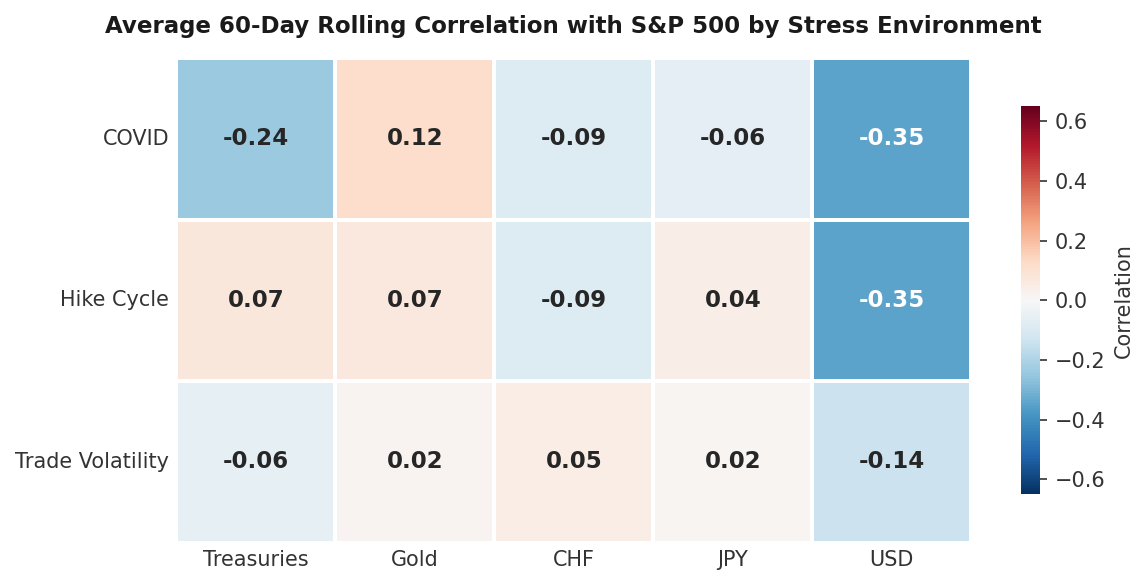

Saved: chart4_heatmap.png
                  Treasuries   Gold    CHF    JPY    USD
COVID                 -0.240  0.120 -0.088 -0.061 -0.349
Hike Cycle             0.074  0.070 -0.087  0.041 -0.348
Trade Volatility      -0.059  0.017  0.050  0.015 -0.137


In [56]:
# ── CHART 4: Correlation Heatmap ─────────────────────────────────────────────
avg_corr_data = {}
for rname in REGIMES:
    mask = regime_mask(df, rname)
    avg_corr_data[rname] = {
        lab: roll_corr.loc[mask, col].mean()
        for col, lab in zip(asset_cols, asset_labels)
    }

hm_df = pd.DataFrame(avg_corr_data).T

fig, ax = plt.subplots(figsize=(8, 4), facecolor='white')
sns.heatmap(hm_df, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-0.65, vmax=0.65,
            linewidths=1.0, linecolor='white',
            annot_kws={'size': 11, 'weight': 'bold'},
            ax=ax, cbar_kws={'shrink': 0.8, 'label': 'Correlation'})

ax.set_title('Average 60-Day Rolling Correlation with S&P 500 by Stress Environment',
             fontsize=11, fontweight='bold', pad=12)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=10)
ax.tick_params(axis='both', length=0)

plt.tight_layout()
plt.savefig('chart4_heatmap.png', dpi=250, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: chart4_heatmap.png')
print(hm_df.round(3))

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


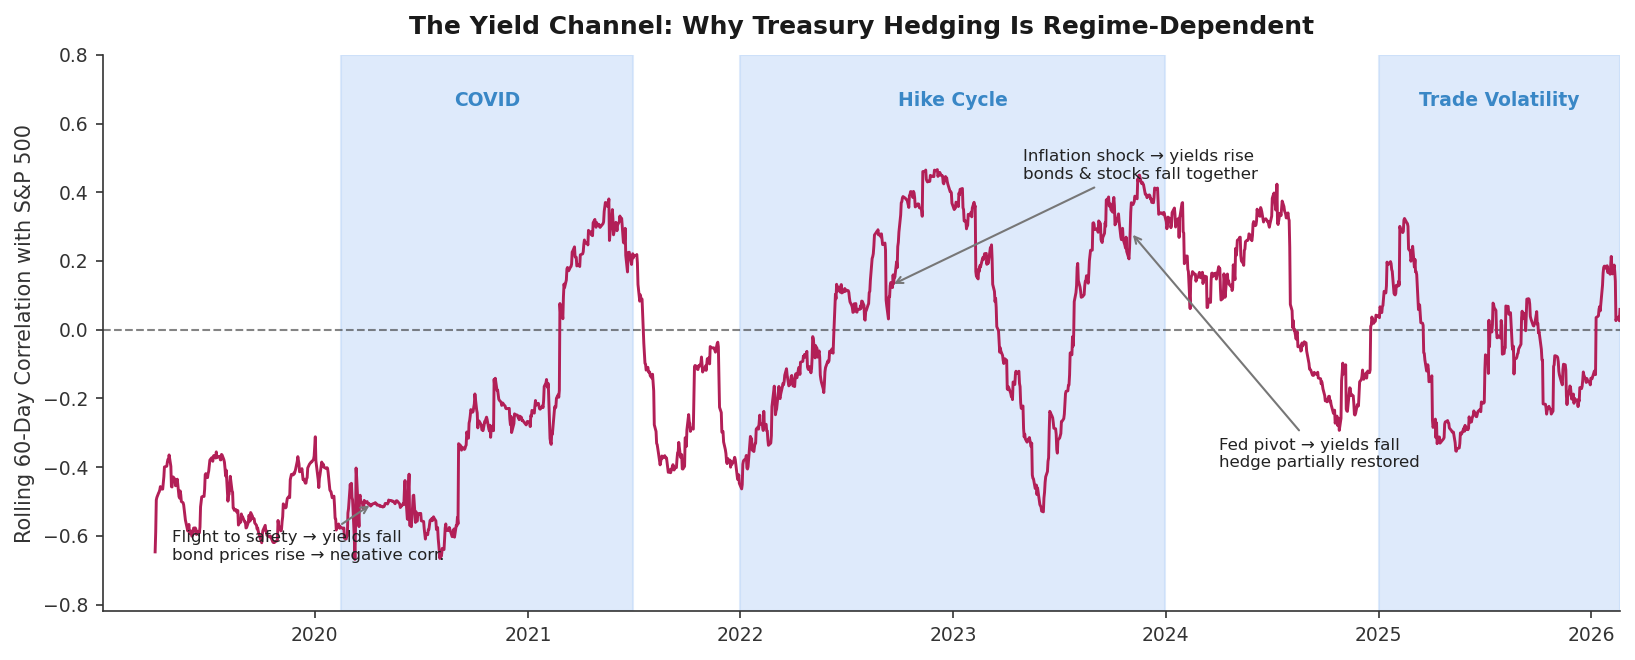

Saved: chart5_discussion_corr.png


In [28]:
# ── CHART 5: Discussion — Yield Channel Annotated ────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4.5), facecolor='white')
ax.set_facecolor('white')

for rname, (rs, re) in REGIMES.items():
    ax.axvspan(pd.Timestamp(rs), pd.Timestamp(re),
               color=C_REGIME_SHADE, alpha=0.5, zorder=1)
    mid = pd.Timestamp(rs) + (pd.Timestamp(re) - pd.Timestamp(rs)) / 2
    ax.text(mid, 0.64, rname, ha='center', va='bottom',
            fontsize=9, fontweight='bold', color=C_REGIME_LABEL)

ax.axhline(0, color='#333333', linewidth=1.0, linestyle='--', alpha=0.6, zorder=2)
ax.plot(roll_corr.index, roll_corr['tsy_ret'],
        color=C_TSY, linewidth=1.4, zorder=3)

# Inline label
ax.text(df.index[40], roll_corr['tsy_ret'].iloc[40] + 0.07,
        '10Y Treasury', fontsize=8, color=C_TSY, fontweight='bold')

# Pin annotation y-coords to actual series values — avoids NaN arrow warnings
_rc5      = roll_corr['tsy_ret'].dropna()
_y5_covid = float(_rc5.loc[_rc5.index >= '2020-04-10'].iloc[0])
_y5_hike  = float(_rc5.loc[_rc5.index >= '2022-09-15'].iloc[0])
_y5_pivot = float(_rc5.loc[_rc5.index >= '2023-11-01'].iloc[0])

ax.annotate('Flight to safety → yields fall\nbond prices rise → negative corr.',
            xy=(pd.Timestamp('2020-04-10'), _y5_covid),
            xytext=(pd.Timestamp('2019-05-01'), -0.67),
            fontsize=8, color='#222222',
            arrowprops=dict(arrowstyle='->', color='#777777', lw=1.0))

ax.annotate('Inflation shock → yields rise\nbonds & stocks fall together',
            xy=(pd.Timestamp('2022-09-15'), _y5_hike),
            xytext=(pd.Timestamp('2023-05-01'), 0.44),
            fontsize=8, color='#222222',
            arrowprops=dict(arrowstyle='->', color='#777777', lw=1.0))

ax.annotate('Fed pivot → yields fall\nhedge partially restored',
            xy=(pd.Timestamp('2023-11-01'), _y5_pivot),
            xytext=(pd.Timestamp('2024-04-01'), -0.40),
            fontsize=8, color='#222222',
            arrowprops=dict(arrowstyle='->', color='#777777', lw=1.0))

ax.set_title('The Yield Channel: Why Treasury Hedging Is Regime-Dependent',
             fontsize=12, fontweight='bold', pad=10)
ax.set_ylabel('Rolling 60-Day Correlation with S&P 500', fontsize=10)
ax.set_ylim(-0.82, 0.80)
ax.set_xlim(df.index[0], df.index[-1])
ax.tick_params(labelsize=9)
plt.tight_layout()
plt.savefig('chart5_discussion_corr.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: chart5_discussion_corr.png')

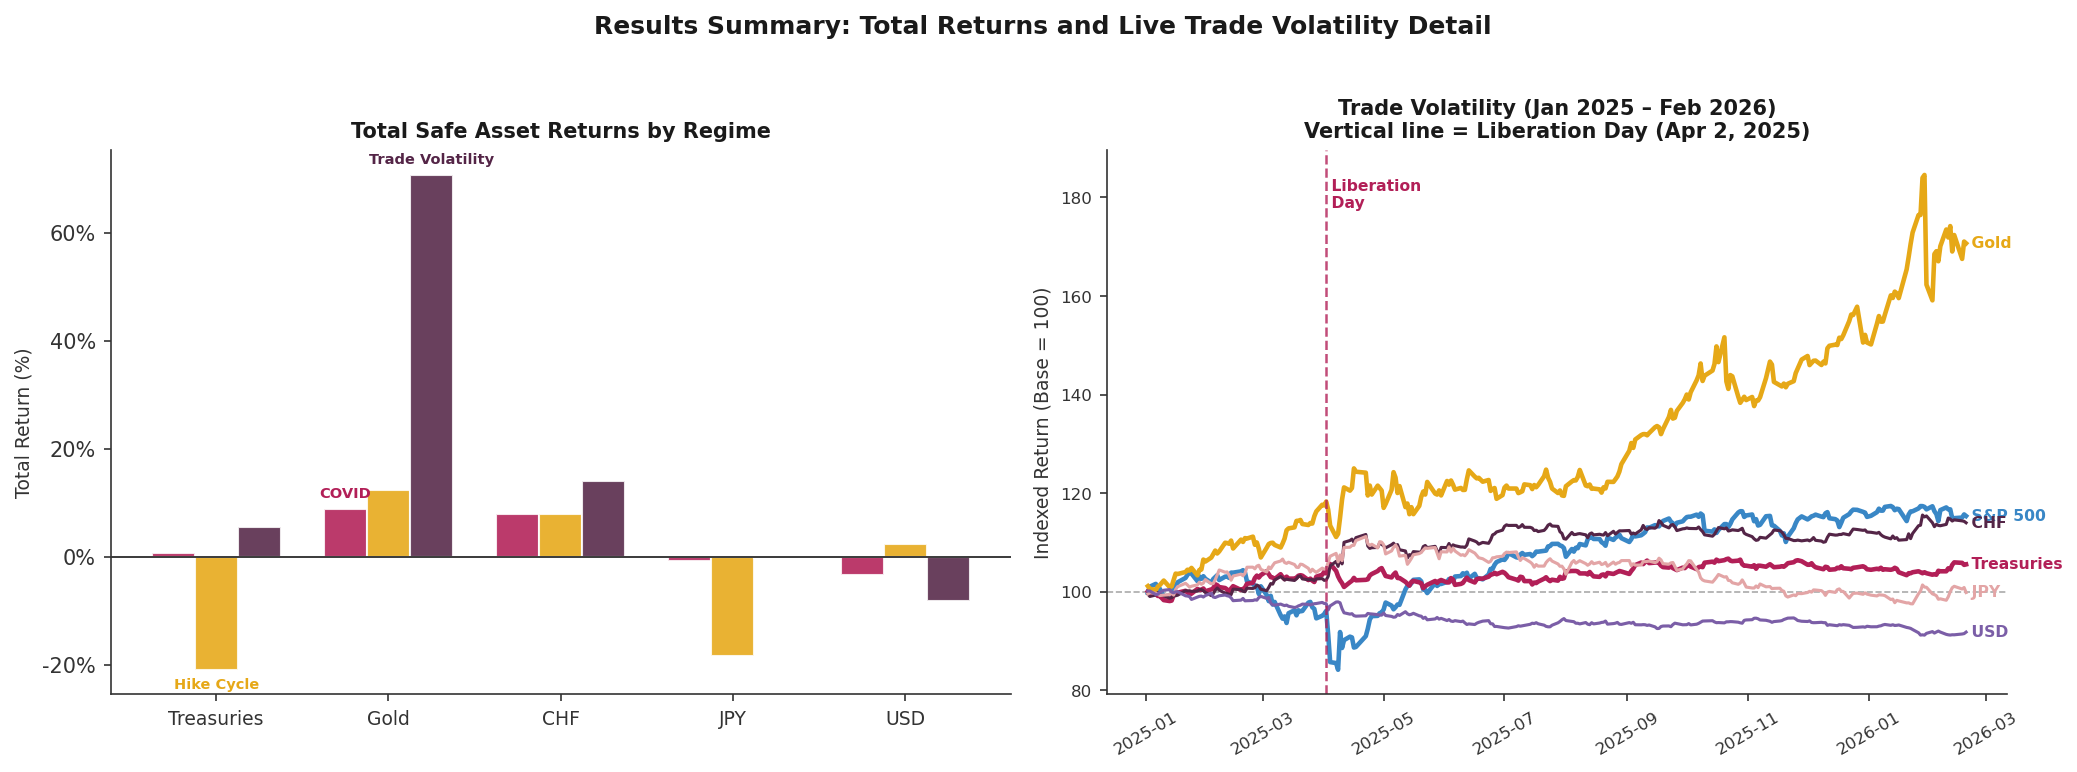

Saved: chart6_results_summary.png


In [29]:
# ── CHART 6: Total Returns + Trade Vol Close-Up ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')

# LEFT: grouped total returns
ax = axes[0]
total_rets = {}
for rname in REGIMES:
    mask = regime_mask(df, rname)
    sub  = df[mask]
    total_rets[rname] = {
        lab: ((1 + sub[col]).prod() - 1) * 100
        for col, lab in zip(asset_cols, asset_labels)
    }

x = np.arange(len(asset_labels))
w = 0.25
regime_bar_colors = [C_TSY, C_GOLD, C_CHF]

for i, (rname, clr) in enumerate(zip(REGIMES, regime_bar_colors)):
    vals = [total_rets[rname][lab] for lab in asset_labels]
    ax.bar(x + i*w, vals, width=w, color=clr, alpha=0.88, edgecolor='white')

for i, (rname, clr) in enumerate(zip(REGIMES, regime_bar_colors)):
    vals = [total_rets[rname][lab] for lab in asset_labels]
    max_idx = int(np.argmax([abs(v) for v in vals]))
    max_val = vals[max_idx]
    
    # Place label above positive bars, below negative bars
    if max_val >= 0:
        ypos = max_val + 1.5
        va = 'bottom'
    else:
        ypos = max_val - 1.5
        va = 'top'
    
    ax.text(max_idx + i*w, ypos, rname,
            ha='center', va=va, fontsize=7,
            color=clr, fontweight='bold')

ax.axhline(0, color='#333333', linewidth=0.9)
ax.set_xticks(x + w)
ax.set_xticklabels(asset_labels, fontsize=9)
ax.set_ylabel('Total Return (%)', fontsize=9)
ax.set_title('Total Safe Asset Returns by Regime', fontsize=10, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f%%'))
ax.set_facecolor('white')

# RIGHT: Trade Volatility close-up
ax2 = axes[1]
ax2.set_facecolor('white')
mask_tv = regime_mask(df, 'Trade Volatility')
sub_tv  = df[mask_tv]
ax2.axhline(100, color='#AAAAAA', linewidth=0.8, linestyle='--')

for col, lab, clr in asset_map:
    if col not in sub_tv.columns:
        continue
    idx = (1 + sub_tv[col]).cumprod() * 100
    lw  = 2.2 if col in ('tsy_ret', 'gold_ret', 'spx_ret') else 1.5
    ax2.plot(idx.index, idx.values, color=clr, linewidth=lw)
    ax2.text(sub_tv.index[-1], idx.iloc[-1], f' {lab}',
             fontsize=7.5, color=clr, va='center', fontweight='bold')

# Liberation Day marker — AFTER all lines plotted so ylim is correct
ax2.autoscale()
ymin, ymax = ax2.get_ylim()
ax2.axvline(LIBERATION_DAY, color='#b21f57', linewidth=1.2, linestyle='--', alpha=0.8)
ax2.text(LIBERATION_DAY, ymax * 0.97, ' Liberation\n Day',
         fontsize=7.5, color='#b21f57', fontweight='bold', va='top')

ax2.set_title('Trade Volatility (Jan 2025 – Feb 2026)\nVertical line = Liberation Day (Apr 2, 2025)',
              fontsize=10, fontweight='bold')
ax2.set_ylabel('Indexed Return (Base = 100)', fontsize=9)
ax2.tick_params(axis='x', rotation=30, labelsize=8)
ax2.tick_params(axis='y', labelsize=8)

fig.suptitle('Results Summary: Total Returns and Live Trade Volatility Detail',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart6_results_summary.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: chart6_results_summary.png')

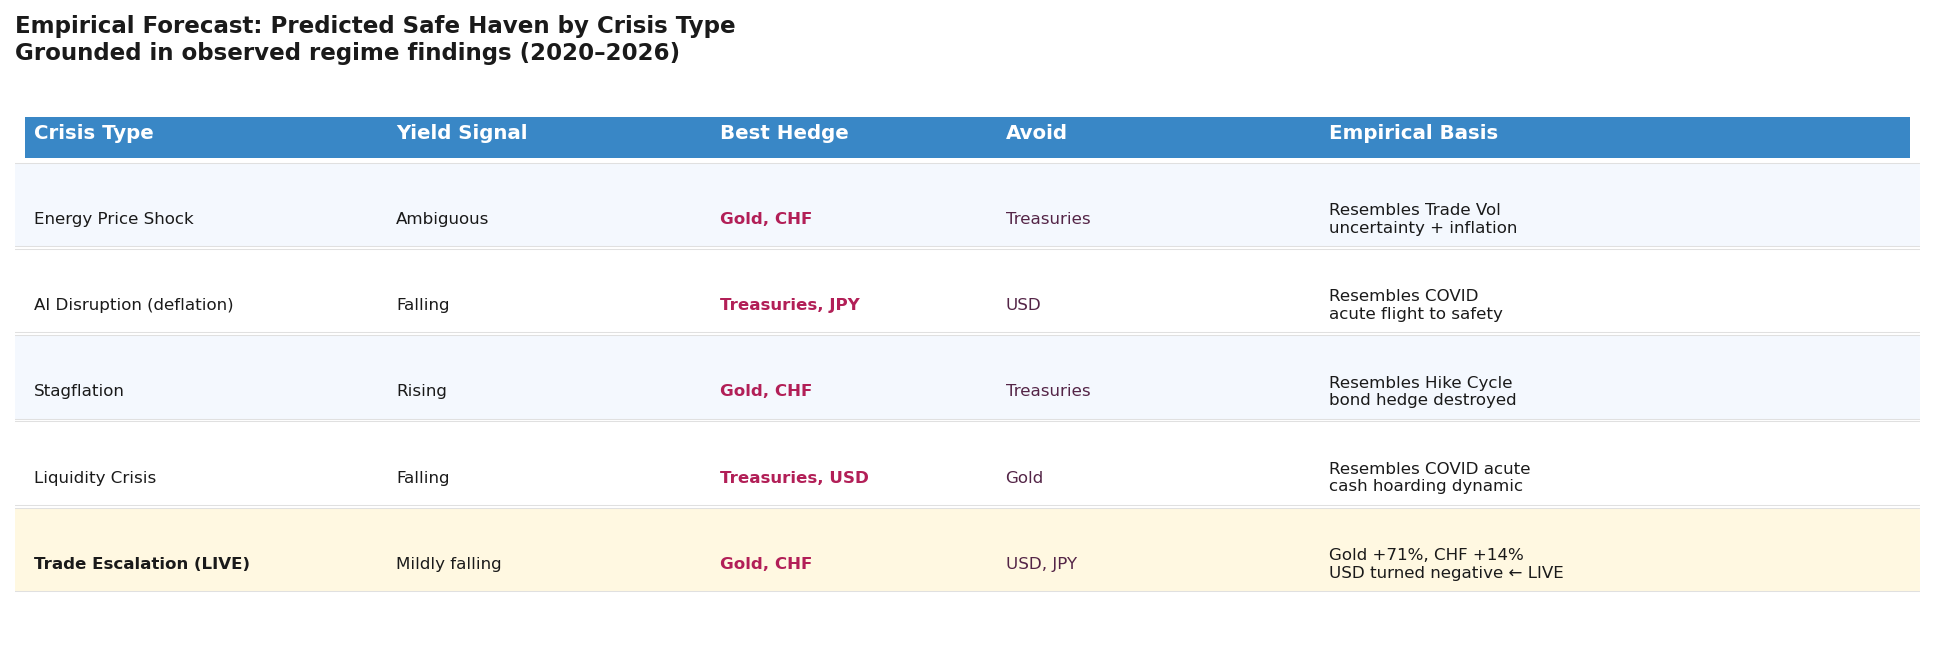

Saved: chart7_scenario_table.png


In [30]:
# ── CHART 7: Empirical Scenario Forecast Table ───────────────────────────────
scenarios = [
    {'crisis': 'Energy Price Shock',       'yield': 'Ambiguous',    'best': 'Gold, CHF',       'worst': 'Treasuries',   'basis': 'Resembles Trade Vol\nuncertainty + inflation'},
    {'crisis': 'AI Disruption (deflation)','yield': 'Falling',      'best': 'Treasuries, JPY', 'worst': 'USD',          'basis': 'Resembles COVID\nacute flight to safety'},
    {'crisis': 'Stagflation',              'yield': 'Rising',        'best': 'Gold, CHF',       'worst': 'Treasuries',   'basis': 'Resembles Hike Cycle\nbond hedge destroyed'},
    {'crisis': 'Liquidity Crisis',         'yield': 'Falling',       'best': 'Treasuries, USD', 'worst': 'Gold',         'basis': 'Resembles COVID acute\ncash hoarding dynamic'},
    {'crisis': 'Trade Escalation (LIVE)',  'yield': 'Mildly falling','best': 'Gold, CHF',       'worst': 'USD, JPY',     'basis': 'Gold +71%, CHF +14%\nUSD turned negative ← LIVE'},
]

fig, ax = plt.subplots(figsize=(13, 4.5), facecolor='white')
ax.set_facecolor('white')
ax.axis('off')

cols      = ['Crisis Type', 'Yield Signal', 'Best Hedge', 'Avoid', 'Empirical Basis']
col_x     = [0.01, 0.20, 0.37, 0.52, 0.69]
col_widths = [0.19, 0.17, 0.15, 0.17, 0.31]
header_y  = 0.92
row_h     = 0.155

for j, (col, x, w) in enumerate(zip(cols, col_x, col_widths)):
    ax.add_patch(plt.Rectangle((x - 0.005, header_y - 0.045), w, 0.075,
                                transform=ax.transAxes,
                                facecolor=C_REGIME_LABEL, edgecolor='none', zorder=0))
    ax.text(x, header_y, col, fontsize=9.5, fontweight='bold', color='white',
            transform=ax.transAxes, va='center')

for i, s in enumerate(scenarios):
    y  = header_y - (i + 1) * row_h
    bg = '#FFF8E1' if i == len(scenarios) - 1 else ('#F4F8FE' if i % 2 == 0 else 'white')
    ax.add_patch(plt.Rectangle((-0.005, y - 0.048), 1.01, row_h - 0.005,
                                transform=ax.transAxes,
                                facecolor=bg, edgecolor='#E0E0E0',
                                linewidth=0.5, zorder=0))
    for j, (val, x) in enumerate(zip(
            [s['crisis'], s['yield'], s['best'], s['worst'], s['basis']], col_x)):
        color = C_TSY if j == 2 else (C_CHF if j == 3 else '#1a1a1a')
        fw    = 'bold' if j == 2 else ('bold' if i == len(scenarios)-1 and j == 0 else 'normal')
        ax.text(x, y, val, fontsize=8, color=color, fontweight=fw,
                transform=ax.transAxes, va='center')

ax.set_title('Empirical Forecast: Predicted Safe Haven by Crisis Type\n'
             'Grounded in observed regime findings (2020–2026)',
             fontsize=11, fontweight='bold', pad=14, loc='left')
plt.tight_layout()
plt.savefig('chart7_scenario_table.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: chart7_scenario_table.png')

---
## Final Poster Chart Assignment

| Poster Section | Chart | File |
|---|---|---|
| **Introduction** | Treasury correlation hook — sign flip story | `chart1_intro_rolling_corr.png` |
| **Results** | Cumulative returns hero — three regimes side by side | `chart3_cumulative_returns.png` |
| **Results** | Heatmap — avg correlation all assets × regimes | `chart4_heatmap.png` |
| **Results** | Bootstrap stress-day bars + 95% CI | `chart2_bootstrap_stress.png` |
| **Discussion** | Yield channel annotated — mechanism explanation | `chart5_discussion_corr.png` |
| **Discussion** | Total returns + Liberation Day close-up | `chart6_results_summary.png` |
| **Discussion/Conclusion** | Empirical scenario forecast table | `chart7_scenario_table.png` |

---
## Key Findings Summary

- **COVID**: Treasuries (+0.59%/day, CI excludes zero ✓) and USD (+0.34% ✓) are the only reliable stress-day hedges
- **Hike Cycle**: USD still works (+0.21% ✓). JPY turns *negative* (−0.13% ✓ but wrong direction). Treasuries provide nothing
- **Trade Volatility**: No asset achieves significance on stress days (n=29). But Gold +71% and CHF +14% total return signal slow-burning safe haven demand
- **USD sign flip**: USD turns negative during Trade Volatility — historically unusual. When the US is the source of the shock, dollar safe-haven demand breaks down
- **Gold as volatility hedge**: Gold does not spike on acute stress days — it grinds higher throughout uncertainty regimes. A regime-level hedge, not a crisis-day hedge


---
## Limitations & Robustness Notes

### 1. Approximate Treasury Return Construction
Treasury returns are estimated using a simplified Macaulay duration formula:
`duration = 10 / (1 + y)`, applied to daily yield changes from FRED DGS10.
This is a **par-bond approximation** — it does not account for convexity, coupon
structure, or the actual modified duration of traded instruments like TLT.
Returns are directionally correct but will slightly overstate price sensitivity,
particularly when yields are low (e.g., 2020–2021, duration ≈ 9.9).

### 2. Regression Multicollinearity (Condition Number ≈ 369)
The interaction-term OLS (Section 5) reports a condition number in the 300–400 range.
This reflects moderate multicollinearity between `spx_ret` and the regime interaction
terms, which share the same underlying series. Robust standard errors (HC3) are used
throughout. Coefficient **signs and significance on the Hike Cycle interaction remain
stable**; COVID and Trade Volatility interactions are less precisely estimated.

### 3. Small Stress-Day Sample Sizes
Block bootstrap CIs are computed over:
- COVID: ~29–94 stress days (depending on threshold)
- Trade Volatility: ~31 stress days

With block size = 5, effective independent blocks ≈ 6–19. CIs are honest about
this uncertainty (most span zero for Trade Volatility). Results should be treated
as **directionally indicative**, not precise point estimates, for these regimes.

### 4. Trade Volatility Regime Is Incomplete
The Trade Volatility regime ends at the data cutoff (2026-02-19). The null
stress-day results may reflect **low statistical power** from an incomplete sample
rather than a genuine absence of safe-haven behavior. Gold's +71% cumulative return
over the regime suggests slow-building demand not captured by acute stress-day tests.

### 5. Scenario Forecast Table Is Qualitative
Chart 7 (Empirical Scenario Forecast Table) represents **analyst inference by regime
analogy** — it is not a statistical forecast. Predictions are grounded in observed
regime findings but involve subjective judgment about which historical period most
closely resembles each hypothetical crisis type. This should be labeled clearly on
the poster as "author projections based on regime analogs."

### 6. COVID Regime Rationale
The COVID regime is defined as **2020-02-15 to 2021-06-30**, intentionally extended
beyond the acute crash to capture the full stimulus-driven recovery period (CARES Act
March 2020, American Rescue Plan March 2021, stimulus checks April 2021). This
captures the complete episode during which monetary and fiscal policy jointly
suppressed yields and supported equities — the full context for Treasury hedging behavior.


In [31]:
# ── Section 5: Regime-Interaction OLS Regression (Treasury ~ SPX) ────────────
# Tests whether the Treasury–equity beta shifts significantly across regimes.
# Model: tsy_ret = α + β₀·spx + β₁·(spx×COVID) + β₂·(spx×Hike) + β₃·(spx×Trade) + ε
# Baseline is 'Calm' periods; interaction terms capture incremental beta shifts.

# Recompute regime dummies in case regime dates were updated above
df['d_covid'] = ((df.index >= '2020-02-15') & (df.index <= '2021-06-30')).astype(int)
df['d_hike']  = ((df.index >= '2022-01-01') & (df.index <= '2023-12-31')).astype(int)
df['d_trade'] = ((df.index >= '2025-01-02') & (df.index <= '2026-02-19')).astype(int)

# Interaction terms: spx_ret × each regime dummy
df['spx_x_covid'] = df['spx_ret'] * df['d_covid']
df['spx_x_hike']  = df['spx_ret'] * df['d_hike']
df['spx_x_trade'] = df['spx_ret'] * df['d_trade']

X2 = sm.add_constant(df[['spx_ret', 'spx_x_covid', 'spx_x_hike', 'spx_x_trade']])
y2 = df['tsy_ret']

model2 = sm.OLS(y2, X2).fit(cov_type='HC3')   # HC3 = heteroskedasticity-robust SEs
print(model2.summary())
print(f"\nCondition number: {np.linalg.cond(X2.values):.1f}  (>30 = mild collinearity concern)")
print("Note: Interaction terms are orthogonal across regimes by construction;")
print("      collinearity arises only from overlap with the base spx_ret term.")


                            OLS Regression Results                            
Dep. Variable:                tsy_ret   R-squared:                       0.049
Model:                            OLS   Adj. R-squared:                  0.047
Method:                 Least Squares   F-statistic:                     11.57
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           2.86e-09
Time:                        22:58:26   Log-Likelihood:                 6683.3
No. Observations:                1769   AIC:                        -1.336e+04
Df Residuals:                    1764   BIC:                        -1.333e+04
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -4.815e-06      0.000     -0.036      

In [32]:
# ── Quick sanity check: params and feature names ─────────────────────────────
print("Params:", model2.params.round(6).to_dict())
print("Features:", model2.model.exog_names)


Params: {'const': -5e-06, 'spx_ret': -0.141246, 'spx_x_covid': 0.039828, 'spx_x_hike': 0.223179, 'spx_x_trade': 0.078875}
Features: ['const', 'spx_ret', 'spx_x_covid', 'spx_x_hike', 'spx_x_trade']


In [33]:
# ── Pairwise vs calm baseline ─────────────────────────────────────────────────
names = model2.model.exog_names  # ['const', 'spx_ret', 'spx_x_covid', 'spx_x_hike', 'spx_x_trade']

print(f"Each regime vs calm baseline:")
print(f"{'Test':<35} {'Beta':>8} {'t-stat':>8} {'p-value':>8} {'Sig':>5}")
print('─' * 68)
for idx, label in [(2, 'COVID vs Calm'),
                   (3, 'Hike Cycle vs Calm'),
                   (4, 'Trade Vol vs Calm')]:
    coef  = model2.params[idx]
    tstat = model2.tvalues[idx]
    pval  = model2.pvalues[idx]
    stars = '***' if pval<0.001 else '**' if pval<0.01 else '*' if pval<0.05 else 'n.s.'
    print(f"{label:<35} {coef:>+8.4f} {tstat:>8.3f} {pval:>8.4f} {stars:>5}")

# ── Direct regime vs regime ───────────────────────────────────────────────────
print(f"\nDirect regime vs regime:")
print(f"{'Test':<35} {'F-stat':>8} {'p-value':>8} {'Sig':>5}")
print('─' * 60)
for hyp, label in [
    ('spx_x_covid = spx_x_hike',  'COVID vs Hike Cycle'),
    ('spx_x_covid = spx_x_trade', 'COVID vs Trade Vol'),
    ('spx_x_hike  = spx_x_trade', 'Hike Cycle vs Trade Vol'),
]:
    ft    = model2.f_test(hyp)
    fval  = float(ft.statistic)
    pval  = ft.pvalue
    stars = '***' if pval<0.001 else '**' if pval<0.01 else '*' if pval<0.05 else 'n.s.'
    print(f"{label:<35} {fval:>8.4f} {pval:>8.4f} {stars:>5}")

# ── Implied betas ─────────────────────────────────────────────────────────────
print(f"\nImplied Treasury–equity beta by regime:")
print(f"  Calm:       {model2.params[1]:+.4f}")
print(f"  COVID:      {model2.params[1] + model2.params[2]:+.4f}")
print(f"  Hike Cycle: {model2.params[1] + model2.params[3]:+.4f}")
print(f"  Trade Vol:  {model2.params[1] + model2.params[4]:+.4f}")
print(f"\nCondition number: {np.linalg.cond(X2.values):.1f}")

Each regime vs calm baseline:
Test                                    Beta   t-stat  p-value   Sig
────────────────────────────────────────────────────────────────────
COVID vs Calm                        +0.0398    0.997   0.3188  n.s.
Hike Cycle vs Calm                   +0.2232    4.936   0.0000   ***
Trade Vol vs Calm                    +0.0789    1.865   0.0622  n.s.

Direct regime vs regime:
Test                                  F-stat  p-value   Sig
────────────────────────────────────────────────────────────
COVID vs Hike Cycle                  17.4638   0.0000   ***
COVID vs Trade Vol                    0.9065   0.3412  n.s.
Hike Cycle vs Trade Vol               9.8177   0.0018    **

Implied Treasury–equity beta by regime:
  Calm:       -0.1412
  COVID:      -0.1014
  Hike Cycle: +0.0819
  Trade Vol:  -0.0624

Condition number: 441.5


In [52]:
# ── Descriptive Statistics by Asset and Regime ────────────────────────────────
for rname in REGIMES:
    mask = regime_mask(df, rname)
    sub  = df[mask]
    print(f"\n{rname}")
    print(f"{'Asset':<14} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8} {'Skew':>8}")
    print('─' * 55)
    for col, lab, clr in asset_map:
        if col in sub.columns:
            s = sub[col] * 100
            print(f"{lab:<14} {s.mean():>+7.3f}% {s.std():>7.3f}% {s.min():>+7.3f}% {s.max():>+7.3f}% {s.skew():>7.3f}")


COVID
Asset              Mean      Std      Min      Max     Skew
───────────────────────────────────────────────────────
S&P 500         +0.058%   1.935% -12.765%  +8.968%  -0.933
Treasuries      +0.003%   0.510%  -2.871%  +2.085%  -0.047
Gold            +0.034%   1.306%  -5.107%  +5.778%  -0.314
CHF             +0.024%   0.466%  -2.260%  +1.959%  -0.190
JPY             -0.001%   0.484%  -2.669%  +2.198%  -0.363
USD             -0.009%   0.375%  -1.910%  +1.875%   0.554

Hike Cycle
Asset              Mean      Std      Min      Max     Skew
───────────────────────────────────────────────────────
S&P 500         -0.005%   1.229%  -4.420%  +5.395%  -0.122
Treasuries      -0.044%   0.739%  -2.707%  +2.890%   0.273
Gold            +0.028%   0.901%  -2.826%  +3.107%   0.092
CHF             +0.017%   0.535%  -1.791%  +2.843%   0.581
JPY             -0.038%   0.661%  -2.503%  +3.796%   0.417
USD             +0.005%   0.369%  -1.320%  +1.106%  -0.119

Trade Volatility
Asset              Mean